## I am creating a new linear regression project to predict advertisement prices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv("./Datasets/Advertising Budget and Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [9]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

### Correlation analysis

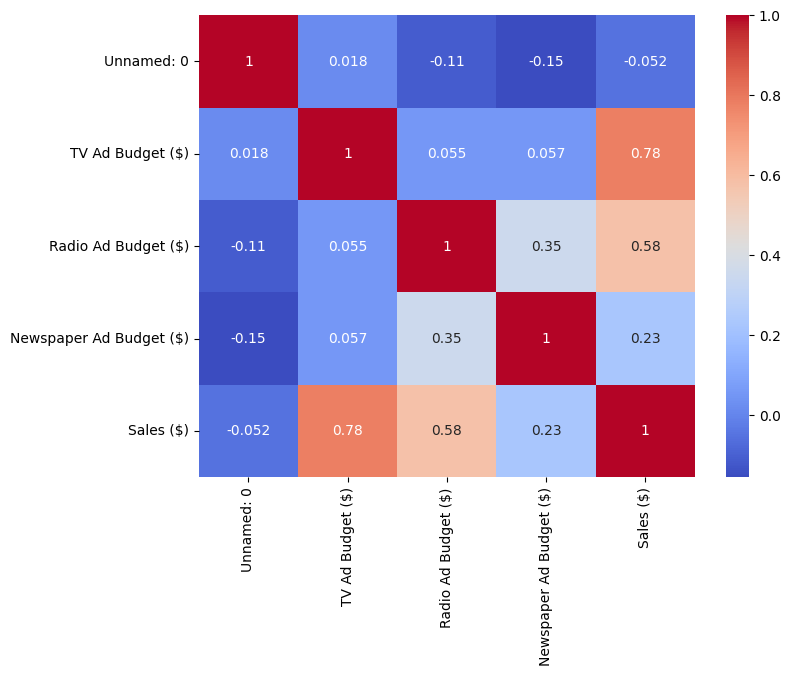

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Define features and target

In [17]:
X = df[['TV Ad Budget ($)',
        'Radio Ad Budget ($)',
        'Newspaper Ad Budget ($)']]

y = df['Sales ($)']

## Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

### Train Model

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Predictions

In [22]:
y_pred = model.predict(X_test)

## Evaluation

In [25]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.4607567168117608
MSE : 3.1740973539761073
RMSE: 1.781599661533451
R² Score: 0.8994380241009119


### Model coefficients

In [26]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

                   Feature  Coefficient
0         TV Ad Budget ($)     0.044730
1      Radio Ad Budget ($)     0.189195
2  Newspaper Ad Budget ($)     0.002761
Intercept: 2.9790673381226327


### Actual vs Predicted


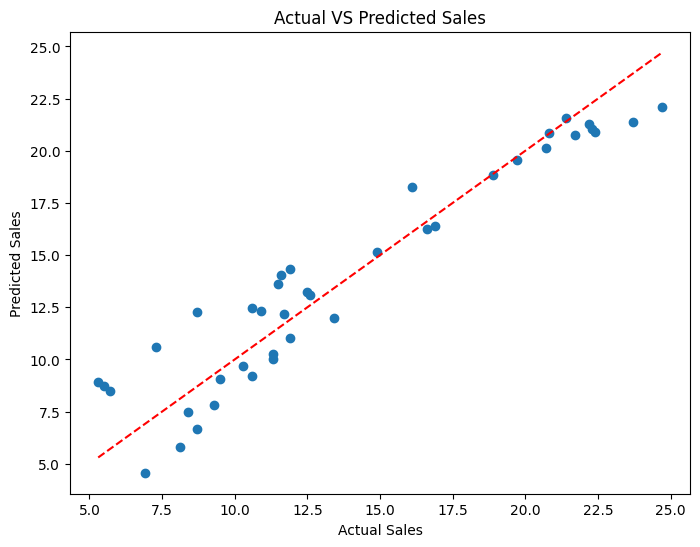

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--') #perfect line
plt.title("Actual VS Predicted Sales")
plt.show()

### Predict for new advertising budgets ##Interactive##

In [29]:
tv = float(input("TV Ad Budget ($): "))
radio = float(input("Radio Ad Budget ($): "))
newspaper = float(input("Newspaper Ad Budget ($): "))

new_data = pd.DataFrame({
    'TV Ad Budget ($)': [tv],
    'Radio Ad Budget ($)': [radio],
    'Newspaper Ad Budget ($)': [newspaper]
})

prediction = model.predict(new_data)

print(f"\nPredicted Sales: ${prediction[0]:,.2f}")


Predicted Sales: $12.47
